In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#Importing all 3 files, grouping them to see each contributor's total contribution, and sorting them in descending order.
#Replace csv names with the names of your files. 
df1 = pd.read_csv('Cleo Fields.csv')
df1 = df1.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)

df2 = pd.read_csv('Henry Cuellar.csv')
df2 = df2.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)

df3 = pd.read_csv('George Latimer.csv')
df3 = df3.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)

/var/folders/kd/vbb_z2sx1v77lx3gryhm1l680000gn/T/ipykernel_26285/3753449667.py:15: DtypeWarning: Columns (40,41,42,43,44,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('George Latimer.csv')


In [ ]:
def classify_contributor(name):
    name = name.upper()
    
    fossil_keywords = ["ENERGY", "OIL", "GAS", "PETROLEUM", "COAL", "PIPELINE"]
    green_keywords = ["SOLAR", "WIND", "RENEWABLE", "CLIMATE"]
    
    if any(k in name for k in fossil_keywords):
        return "fossil"
    elif any(k in name for k in green_keywords):
        return "green"
    return "other"


def build_member_lists(df):
    fossil = []
    green = []
    
    for name in df["contributor_name"]:
        category = classify_contributor(name)
        
        if category == "fossil":
            fossil.append(name)
        elif category == "green":
            green.append(name)
    
    return fossil[:5], green[:5]


def filter_by_keywords(df, keywords):
    pattern = "|".join(keywords)
    return df[df["contributor_name"].str.contains(pattern, case=False, na=False)]

keywords = [
    "ENERGY",
    "OIL",
    "GAS",
    "AIR",
    "ELECTRIC",
    "PETROLEUM",
    "COAL",
    "PIPELINE"
]


df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)
df1 = filter_by_keywords(df1, keywords)

df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)
df2 = filter_by_keywords(df2, keywords)

df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)
df3 = filter_by_keywords(df3, keywords)


In [39]:
df1.head(10)

,contributor_name,contribution_receipt_amount,stance,target
176,ENERGY LLC,1500.0,orange,Cleo Fields
274,JBOLT ELECTRICAL LLC,1500.0,gray,Cleo Fields
163,"DUGAS, SARA",1000.0,orange,Cleo Fields
439,"RAGAS, RENE",1000.0,orange,Cleo Fields
513,THE AMERICAN ELECTRIC POWER COMMITTEE FOR RESP...,1000.0,gray,Cleo Fields


In [43]:
df2.head(10)

,contributor_name,contribution_receipt_amount,stance,target
958,US ENERGY PAC (THE PAC OF AMERICAN EXPLORATION...,10000.0,orange,Henry Cuellar
66,AMERICAN PETROLEUM INSTITUTE POLITICAL ACTION ...,10000.0,orange,Henry Cuellar
180,"CHENIERE ENERGY, INC. PAC",7000.0,orange,Henry Cuellar
579,MARATHON OIL COMPANY EMPLOYEES POLITICAL ACTIO...,5500.0,orange,Henry Cuellar
580,MARATHON PETROLEUM CORPORATION EMPLOYEES POLIT...,5000.0,orange,Henry Cuellar
968,VALERO ENERGY CORPORATION POLITICAL ACTION COM...,5000.0,gray,Henry Cuellar
246,DEVON ENERGY CORPORATION POLITICAL ACTION COMM...,5000.0,gray,Henry Cuellar
670,NATIONAL ELECTRICAL CONTRACTORS ASSOCIATION PO...,5000.0,gray,Henry Cuellar
704,NUSTAR ENERGY L.P. (NUSTAR PAC),5000.0,gray,Henry Cuellar
706,OCCIDENTAL PETROLEUM CORPORATION POLITICAL ACT...,5000.0,gray,Henry Cuellar


In [41]:
df3.head(10)

,contributor_name,contribution_receipt_amount,stance,target
3132,NEW DEMOCRAT COALITION ACTION FUND,1000.0,orange,George Latimer
1376,"GASHI, ADRIAN",500.0,orange,George Latimer
1377,"GASHI, ALBAN",500.0,orange,George Latimer


### LOW DEMOCRATIC

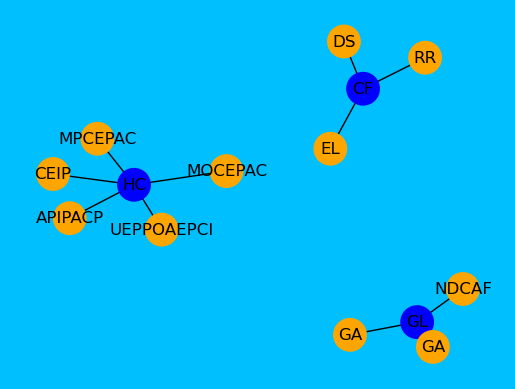

In [38]:
members = [
    {'name': 'Cleo Fields', 'fossil': [], 'green': []},  
    {'name': 'Henry Cuellar', 'fossil': [], 'green': []},  
    {'name': 'George Latimer', 'fossil': [], 'green': []}
]

Gs = [nx.Graph(), nx.Graph(), nx.Graph()]

dfs = [df1, df2, df3]

for i, df in enumerate(dfs):
    fossil, green = build_member_lists(df)
    
    members[i]["fossil"] = fossil
    members[i]["green"] = green

for i, (df, m) in enumerate(zip(dfs, members)):
    df["stance"] = "gray"
    df["target"] = m["name"]

    # Play around with these colors if you'd like, defaults are orange and green.
    df.loc[df["contributor_name"].isin(m["fossil"]), "stance"] = "orange"
    df.loc[df["contributor_name"].isin(m["green"]), "stance"] = "green"

    Gs[i] = nx.from_pandas_edgelist(
        df[df["contributor_name"].isin(m["fossil"] + m["green"])],
        source="contributor_name",
        target="target",
        edge_attr=["stance"]
    )
    


    for _, row in df.iterrows():
        if row["contributor_name"] in Gs[i].nodes:
            Gs[i].nodes[row["contributor_name"]]["color"] = row["stance"]

    # If working with Democrats, change to "skyblue"
    if m["name"] in Gs[i].nodes:
        Gs[i].nodes[m["name"]]["color"] = "blue"

G1 = Gs[0]
G1.add_nodes_from(Gs[1].nodes(data=True))
G1.add_nodes_from(Gs[2].nodes(data=True))
G1.add_edges_from(Gs[1].edges(data=True))
G1.add_edges_from(Gs[2].edges(data=True))

key = []
labels = {}
for n in G1.nodes():
    parts = n.split() 
    letters = [p[0] for p in parts if p[0].isalpha()]
    labels[n] = "".join(letters)
    key.append({labels[n] : n})


node_colors = [G1.nodes[n].get("color", "gray") for n in G1.nodes()]

fig, ax = plt.subplots()
pos = nx.spring_layout(G1, k=1, iterations=100)
nx.draw(G1, pos=pos, with_labels=True, labels=labels, node_color=node_colors, node_size=500, edge_color='black', linewidths=2)
ax.axis('off')
#You can change the background color here. 
fig.set_facecolor('deepskyblue')
plt.show()

In [45]:
print("Key: ")
for item in key:
    for k, v in item.items( ):
        print(f"{k} = {v}") 

Key: 
EL = ENERGY LLC
CF = Cleo Fields
DS = DUGAS, SARA
RR = RAGAS, RENE
UEPPOAEPCI = US ENERGY PAC (THE PAC OF AMERICAN EXPLORATION & PRODUCTION COUNCIL, INC.)
HC = Henry Cuellar
APIPACP = AMERICAN PETROLEUM INSTITUTE POLITICAL ACTION COMMITTEE (API PAC)
CEIP = CHENIERE ENERGY, INC. PAC
MOCEPAC = MARATHON OIL COMPANY EMPLOYEES POLITICAL ACTION COMMITTEE (MEPAC)
MPCEPAC = MARATHON PETROLEUM CORPORATION EMPLOYEES POLITICAL ACTION COMMITTEE (MPAC)
NDCAF = NEW DEMOCRAT COALITION ACTION FUND
GL = George Latimer
GA = GASHI, ADRIAN
GA = GASHI, ALBAN
